In [12]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import seaborn as sns

In [8]:

# Load file
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/output_text_files/07_filtered_counts/gse197726_normalized_counts.tsv"

df = pd.read_csv(file_path, sep="\t", index_col=0)

# Clean gene names
df.index = df.index.str.strip().str.upper()

In [9]:
igf = df.loc["ENSMUSG00000033581"]
nr1d2 = df.loc["ENSMUSG00000021775"]

In [10]:
r_all, p_all = pearsonr(igf, nr1d2)

print("All samples (n={}):".format(len(igf)))
print("Pearson r =", round(r_all, 4))
print("p-value   =", p_all)

All samples (n=54):
Pearson r = -0.9572
p-value   = 1.1612657567561492e-29


In [5]:
results = {}

for genotype in ["WT", "KO", "mRE"]:
    cols = [c for c in df.columns if genotype in c]
    
    igf_sub = igf[cols]
    nr1d2_sub = nr1d2[cols]
    
    r, p = pearsonr(igf_sub, nr1d2_sub)
    
    results[genotype] = {
        "n": len(cols),
        "r": r,
        "p": p
    }

# Print results
for g in results:
    print(f"\n{g} samples (n={results[g]['n']}):")
    print("Pearson r =", round(results[g]['r'], 4))
    print("p-value   =", results[g]['p'])


WT samples (n=18):
Pearson r = -0.7629
p-value   = 0.0002312735817532249

KO samples (n=18):
Pearson r = -0.2086
p-value   = 0.40625930752187966

mRE samples (n=18):
Pearson r = -0.4871
p-value   = 0.04033211102227721


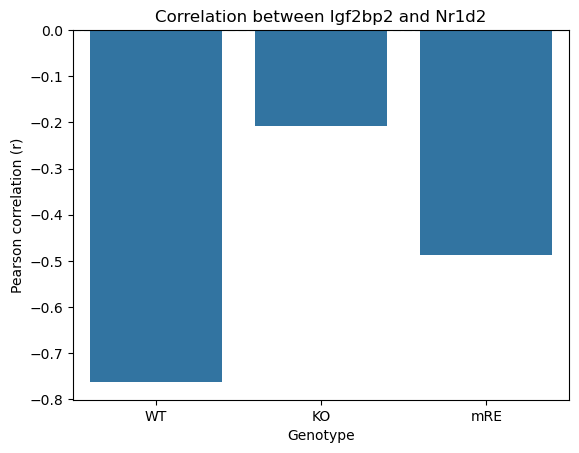

In [14]:
import pandas as pd

res_df = pd.DataFrame(results).T.reset_index()
res_df.rename(columns={"index":"Genotype"}, inplace=True)

sns.barplot(data=res_df, x="Genotype", y="r")
plt.axhline(0, linestyle="--")
plt.ylabel("Pearson correlation (r)")
plt.title("Correlation between Igf2bp2 and Nr1d2")
plt.show()

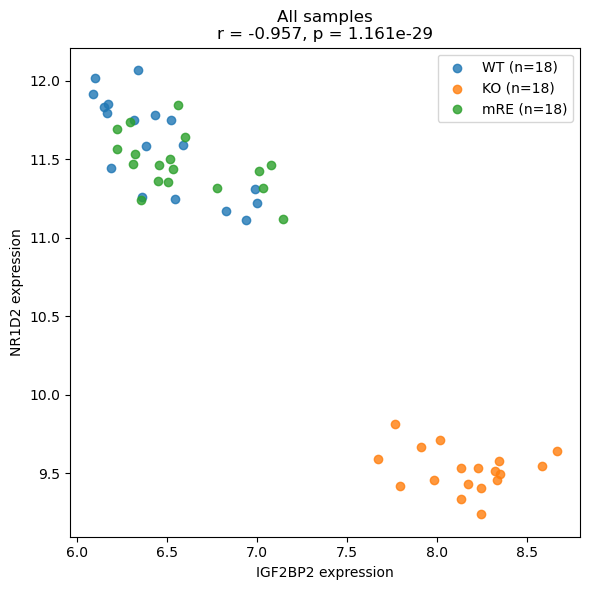

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

colors = {
    "WT": "#1f77b4",     # blue
    "KO": "#ff7f0e",     # orange
    "mRE": "#2ca02c"     # green
}

for genotype in ["WT", "KO", "mRE"]:
    cols = [c for c in df.columns if genotype in c]
    
    igf_sub = igf[cols]
    nr1d2_sub = nr1d2[cols]
    
    plt.scatter(
        igf_sub,
        nr1d2_sub,
        label=f"{genotype} (n={len(cols)})",
        color=colors[genotype],
        alpha=0.8
    )

# overall correlation
r_all, p_all = pearsonr(igf, nr1d2)

plt.xlabel("IGF2BP2 expression")
plt.ylabel("NR1D2 expression")
plt.title(f"All samples\nr = {r_all:.3f}, p = {p_all:.3e}")
plt.legend()
plt.tight_layout()
plt.show()

## GSE107787

In [25]:
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE107787/GSE107787_RNAseq_expression_results.xlsx"

df = pd.read_excel(file_path)

print(df.shape)
# Keep only first 36 columns
df = df.iloc[:, :37]

print("New shape:", df.shape)

# Check structure
print(df.head())
print(df.columns)

(20561, 73)
New shape: (20561, 37)
     Gene  Muscle_FED_ZT00_Rep3  Muscle_FED_ZT00_Rep4  Muscle_FED_ZT00_Rep5  \
0    Xkr4               0.01147               0.01125               0.00000   
1     Rp1               0.04275               0.06528               0.06363   
2   Sox17               1.72219               1.37552               1.89178   
3  Mrpl15              11.43258              13.26742              12.50647   
4  Lypla1              38.52326              34.19680              43.05566   

   Muscle_FED_ZT04_Rep1  Muscle_FED_ZT04_Rep3  Muscle_FED_ZT04_Rep5  \
0               0.01147               0.01210               0.01199   
1               0.01710               0.02255               0.04458   
2               1.40962               1.17231               1.00325   
3              16.05910              12.84987              13.68800   
4              41.50928              33.78573              27.47940   

   Muscle_FED_ZT08_Rep2  Muscle_FED_ZT08_Rep3  Muscle_FED_ZT08_

In [26]:
df["Gene"] = df["Gene"].str.strip().str.upper()
df = df.set_index("Gene")



In [27]:
print(df.head())
print(df.columns)
print("New shape:", df.shape)

        Muscle_FED_ZT00_Rep3  Muscle_FED_ZT00_Rep4  Muscle_FED_ZT00_Rep5  \
Gene                                                                       
XKR4                 0.01147               0.01125               0.00000   
RP1                  0.04275               0.06528               0.06363   
SOX17                1.72219               1.37552               1.89178   
MRPL15              11.43258              13.26742              12.50647   
LYPLA1              38.52326              34.19680              43.05566   

        Muscle_FED_ZT04_Rep1  Muscle_FED_ZT04_Rep3  Muscle_FED_ZT04_Rep5  \
Gene                                                                       
XKR4                 0.01147               0.01210               0.01199   
RP1                  0.01710               0.02255               0.04458   
SOX17                1.40962               1.17231               1.00325   
MRPL15              16.05910              12.84987              13.68800   
LYPLA1     

In [46]:
igf = df.loc["IGF2BP2"]
nr1d2 = df.loc["NR1D2"]

In [47]:
groups = {
    "FED": [c for c in df.columns if "FED" in str(c)],
    "FAST": [c for c in df.columns if "FAST" in str(c)]
}

results = {}

for group, cols in groups.items():
    if len(cols) < 2:
        print(f"{group}: Not enough samples ({len(cols)})")
        continue
    
    r, p = pearsonr(igf[cols], nr1d2[cols])
    
    results[group] = {
        "n": len(cols),
        "r": r,
        "p": p
    }

for g in results:
    print(f"\n{g} samples:")
    print("n =", results[g]["n"])
    print("Pearson r =", round(results[g]["r"], 4))
    print("p-value =", results[g]["p"])


FED samples:
n = 18
Pearson r = -0.6636
p-value = 0.0026757069932820477

FAST samples:
n = 18
Pearson r = -0.4293
p-value = 0.07542956778555732


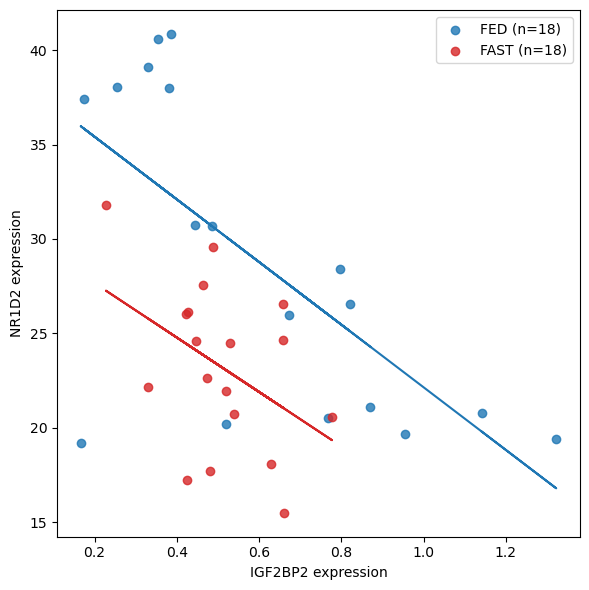

In [31]:
plt.figure(figsize=(6,6))

colors = {
    "FED": "#1f77b4",   # blue
    "FAST": "#d62728"   # red
}

for group, cols in groups.items():
    if len(cols) < 2:
        continue
    
    x = igf[cols]
    y = nr1d2[cols]
    
    plt.scatter(x, y, label=f"{group} (n={len(cols)})",
                color=colors[group], alpha=0.8)
    
    # regression line
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b, color=colors[group])

plt.xlabel("IGF2BP2 expression")
plt.ylabel("NR1D2 expression")
plt.legend()
plt.tight_layout()
plt.show()

## GSE194106

In [61]:
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE194106/GSE194106_RNAseq-muscle-tpm.txt"

df = pd.read_csv(file_path, sep="\t", index_col=0)

In [62]:
print(df.columns[:36])
print(df.head())

Index(['GasD00_1', 'GasD00_2', 'GasD00_3', 'GasD00_4', 'GasD04_1', 'GasD04_2',
       'GasD04_3', 'GasD04_4', 'GasD08_1', 'GasD08_2', 'GasD08_3', 'GasD08_4',
       'GasD12_1', 'GasD12_2', 'GasD12_3', 'GasD12_4', 'GasD16_1', 'GasD16_2',
       'GasD16_3', 'GasD16_4', 'GasD20_1', 'GasD20_2', 'GasD20_3', 'GasD20_4',
       'GasD24_1', 'GasD24_2', 'GasD24_3', 'GasD24_4', 'GasN00_1', 'GasN00_2',
       'GasN00_3', 'GasN00_4', 'GasN04_1', 'GasN04_2', 'GasN04_3', 'GasN04_4'],
      dtype='object')
         GasD00_1   GasD00_2   GasD00_3   GasD00_4   GasD04_1   GasD04_2  \
geneID                                                                     
497097   3.879338   4.990513   2.550108   1.834277   1.390392   1.975372   
19888    2.533132   2.109692   4.659280   2.453637   2.954143   0.977818   
20671   50.791778  39.202107  52.490761  47.861529  45.867976  46.025523   
27395   46.954021  46.213247  44.875500  46.083853  46.918249  47.123559   
18777   65.459083  63.702056  62.552723  64.436

In [64]:
df.index = df.index.astype(str)

In [65]:
igf = df.loc["319765"]
nr1d2 = df.loc["353187"]

In [66]:
gasd_cols = [c for c in df.columns if str(c).startswith("GasD")]
gasn_cols = [c for c in df.columns if str(c).startswith("GasN")]

print("GASD samples:", len(gasd_cols))
print("GASN samples:", len(gasn_cols))

GASD samples: 28
GASN samples: 28


In [67]:
results = {}

for group, cols in {"GASD": gasd_cols, "GASN": gasn_cols}.items():
    
    if len(cols) < 2:
        print(f"{group}: Not enough samples")
        continue
    
    r, p = pearsonr(igf[cols], nr1d2[cols])
    
    results[group] = {
        "n": len(cols),
        "r": r,
        "p": p
    }

for g in results:
    print(f"\n{g}:")
    print("n =", results[g]["n"])
    print("Pearson r =", round(results[g]["r"], 4))
    print("p-value =", results[g]["p"])


GASD:
n = 28
Pearson r = -0.4703
p-value = 0.011544831079345405

GASN:
n = 28
Pearson r = -0.7438
p-value = 5.732005980014664e-06


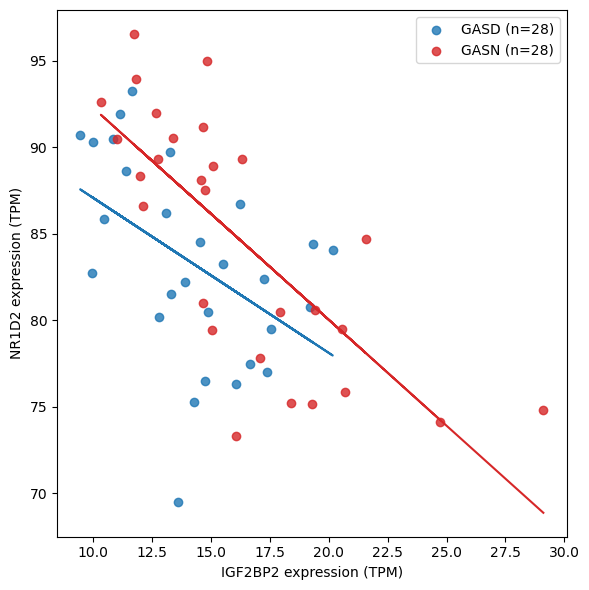

In [68]:
plt.figure(figsize=(6,6))

colors = {
    "GASD": "#1f77b4",   # blue
    "GASN": "#d62728"    # red
}

for group, cols in {"GASD": gasd_cols, "GASN": gasn_cols}.items():
    
    if len(cols) < 2:
        continue
    
    x = igf[cols]
    y = nr1d2[cols]
    
    plt.scatter(x, y,
                label=f"{group} (n={len(cols)})",
                color=colors[group],
                alpha=0.8)
    
    # regression line
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b, color=colors[group])

plt.xlabel("IGF2BP2 expression (TPM)")
plt.ylabel("NR1D2 expression (TPM)")
plt.legend()
plt.tight_layout()
plt.show()

## GSE187117

In [113]:
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Human/GSE182117/GSE182117_logCPM_batchCorrected.tsv"
df = pd.read_csv(file_path, sep="\t",index_col=0)


In [114]:
df.head()
df.columns


Index(['T2D_CTL_12h_i05', 'T2D_CTL_18h_i05', 'T2D_CTL_24h_i05',
       'T2D_CTL_30h_i05', 'T2D_CTL_36h_i05', 'T2D_CTL_42h_i05',
       'T2D_CTL_48h_i05', 'T2D_CTL_54h_i05', 'T2D_HGI_12h_i05',
       'T2D_HGI_18h_i05',
       ...
       'NGT_CTL_48h_i11', 'NGT_CTL_54h_i11', 'NGT_HGI_12h_i11',
       'NGT_HGI_18h_i11', 'NGT_HGI_24h_i11', 'NGT_HGI_30h_i11',
       'NGT_HGI_36h_i11', 'NGT_HGI_42h_i11', 'NGT_HGI_48h_i11',
       'NGT_HGI_54h_i11'],
      dtype='object', length=186)

In [ ]:
df.index = df.index.str.strip().str.upper()
igf = df.loc["ENSG00000073792"]
nr1d2 = df.loc["ENSG00000174738"]
groups = {
    "T2D_CTL": [c for c in df.columns if str(c).startswith("T2D_CTL")],
    "T2D_HGI": [c for c in df.columns if str(c).startswith("T2D_HGI")],
    "NGT_CTL": [c for c in df.columns if str(c).startswith("NGT_CTL")],
    "NGT_HGI": [c for c in df.columns if str(c).startswith("NGT_HGI")]
}

for g in groups:
    print(g, "→", len(groups[g]), "samples")
results = {}

for group, cols in groups.items():
    
    if len(cols) < 2:
        print(f"{group}: Not enough samples")
        continue
    
    r, p = pearsonr(igf[cols], nr1d2[cols])
    
    results[group] = {
        "n": len(cols),
        "r": r,
        "p": p
    }

for g in results:
    print(f"\n{g}:")
    print("n =", results[g]["n"])
    print("Pearson r =", round(results[g]["r"], 4))
    print("p-value =", results[g]["p"])
plt.figure(figsize=(7,6))

colors = {
    "T2D_CTL": "#1f77b4",
    "T2D_HGI": "#ff7f0e",
    "NGT_CTL": "#2ca02c",
    "NGT_HGI": "#d62728"
}

for group, cols in groups.items():
    
    if len(cols) < 2:
        continue
    
    x = igf[cols]
    y = nr1d2[cols]
    
    plt.scatter(x, y,
                label=f"{group} (n={len(cols)})",
                color=colors[group],
                alpha=0.7)
    
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b, color=colors[group])

plt.xlabel("IGF2BP2 expression (logCPM)")
plt.ylabel("NR1D2 expression (logCPM)")
plt.legend()
plt.tight_layout()
plt.show()

## GSE108539

In [118]:
# ----------------------------
# 1️⃣ Load data
# ----------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Human/GSE108539/GSE108539_norm_reads_count.txt"
df = pd.read_csv(file_path, sep="\t", index_col=0)

In [119]:
df.head()
df.columns

Index(['Intron_15_S1_12.00', 'Intron_15_S2_16.00', 'Intron_15_S3_20.00',
       'Intron_15_S4_00.00', 'Intron_15_S5_04.00', 'Intron_15_S6_08.00',
       'Intron_3_S7_12.00', 'Intron_3_S8_16.00', 'Intron_3_S9_20.00',
       'Intron_3_S10_00.00',
       ...
       'Exon_12_S51_20.00', 'Exon_12_S52_00.00', 'Exon_12_S53_04.00',
       'Exon_12_S54_08.00', 'Exon_1_S55_12.00', 'Exon_1_S56_16.00',
       'Exon_1_S57_20.00', 'Exon_1_S58_00.00', 'Exon_1_S59_04.00',
       'Exon_1_S60_08.00'],
      dtype='object', length=114)

In [120]:
exon_cols = [c for c in df.columns if str(c).startswith("Exon")]

igf = df.loc["ENSG00000073792", exon_cols]
nr1d2 = df.loc["ENSG00000174738", exon_cols]



print("Number of Exon samples:", len(exon_cols))
print("Length used in correlation:", len(igf))

Number of Exon samples: 57
Length used in correlation: 57


In [121]:
r, p = pearsonr(igf, nr1d2)

print("Exon samples:")
print("n =", len(igf))
print("Pearson r =", round(r, 4))
print("p-value =", p)

Exon samples:
n = 57
Pearson r = -0.5123
p-value = 4.629184679634963e-05


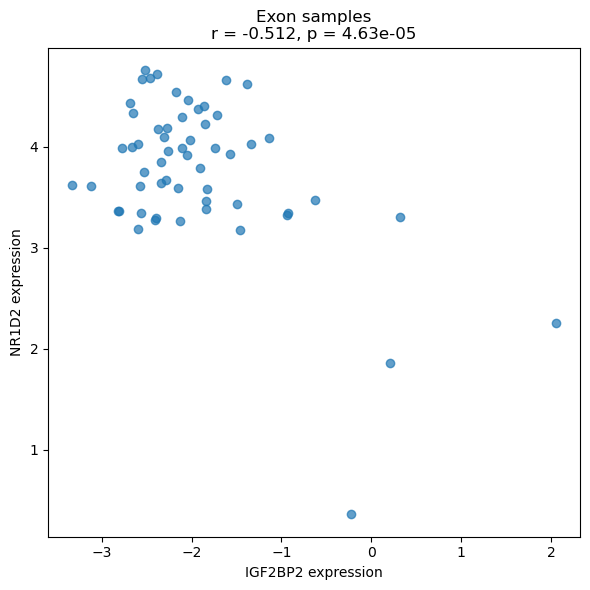

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(igf, nr1d2, alpha=0.7)

# regression line
m, b = np.polyfit(igf, nr1d2, 1)
plt.plot(igf, m*igf + b)

plt.xlabel("IGF2BP2 expression")
plt.ylabel("NR1D2 expression")
plt.title(f"Exon samples\nr = {r:.3f}, p = {p:.2e}")
plt.tight_layout()
plt.show()

## GSE308276

In [126]:
# -------------------------
# 1️⃣ Load Excel
# -------------------------
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/circadian_datasets_for_rhythmicity_analysis/Mouse/GSE308276/GSE308276_FPKM_mus_from_WT_and_Bmal1LKO_6tp.xlsx"
df = pd.read_excel(file_path, index_col=0)


In [128]:
df.head()
df.columns

Index(['B1: WT_ZT0_REP1', 'B2: WT_ZT0_REP2', 'B3: WT_ZT0_REP3',
       'B4: WT_ZT4_REP1', 'B5: WT_ZT4_REP2', 'B6: WT_ZT4_REP3',
       'B7: WT_ZT8_REP1', 'B8: WT_ZT8_REP2', 'B9: WT_ZT8_REP3',
       'B10: WT_ZT12_REP1', 'B11: WT_ZT12_REP2', 'B12: WT_ZT12_REP3',
       'B13: WT_ZT16_REP1', 'B14: WT_ZT16_REP2', 'B15: WT_ZT16_REP3',
       'B16: WT_ZT20_REP1', 'B17: WT_ZT20_REP2', 'B18: WT_ZT20_REP3',
       'B19: KO_ZT0_REP1', 'B20: KO_ZT0_REP2', 'B21: KO_ZT0_REP3',
       'B22: KO_ZT4_REP1', 'B23: KO_ZT4_REP2', 'B24: KO_ZT4_REP3',
       'B25: KO_ZT8_REP1', 'B26: KO_ZT8_REP2', 'B27: KO_ZT8_REP3',
       'B28: KO_ZT12_REP1', 'B29: KO_ZT12_REP2', 'B30: KO_ZT12_REP3',
       'B31: KO_ZT16_REP1', 'B32: KO_ZT16_REP2', 'B33: KO_ZT16_REP3',
       'B34: KO_ZT20_REP1', 'B35: KO_ZT20_REP2', 'B36: KO_ZT20_REP3'],
      dtype='object')

In [129]:
# remove "B1: " prefix
df.columns = [c.split(": ")[1] for c in df.columns]

# clean gene names
df.index = df.index.astype(str).str.strip().str.upper()

print(df.columns[:5])

Index(['WT_ZT0_REP1', 'WT_ZT0_REP2', 'WT_ZT0_REP3', 'WT_ZT4_REP1',
       'WT_ZT4_REP2'],
      dtype='object')


In [130]:
igf = df.loc["IGF2BP2"]
nr1d2 = df.loc["NR1D2"]

In [131]:
wt_cols = [c for c in df.columns if c.startswith("WT")]
ko_cols = [c for c in df.columns if c.startswith("KO")]

print("WT samples:", len(wt_cols))
print("KO samples:", len(ko_cols))

WT samples: 18
KO samples: 18


In [132]:
results = {}

for group, cols in {"WT": wt_cols, "KO": ko_cols}.items():
    
    r, p = pearsonr(
        df.loc["IGF2BP2", cols],
        df.loc["NR1D2", cols]
    )
    
    results[group] = {"n": len(cols), "r": r, "p": p}

for g in results:
    print(f"\n{g}:")
    print("n =", results[g]["n"])
    print("r =", round(results[g]["r"], 4))
    print("p =", results[g]["p"])


WT:
n = 18
r = -0.4624
p = 0.05332625198886638

KO:
n = 18
r = -0.4982
p = 0.03535569095611332


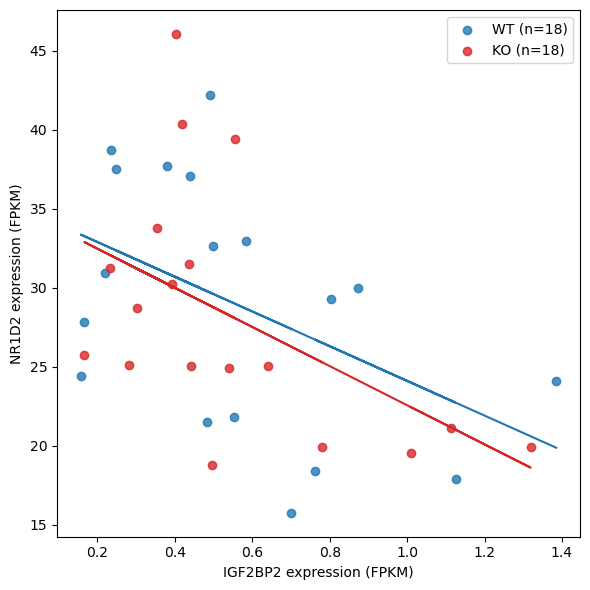

In [133]:
plt.figure(figsize=(6,6))

colors = {"WT": "#1f77b4", "KO": "#d62728"}

for group, cols in {"WT": wt_cols, "KO": ko_cols}.items():
    
    x = df.loc["IGF2BP2", cols]
    y = df.loc["NR1D2", cols]
    
    plt.scatter(x, y,
                label=f"{group} (n={len(cols)})",
                color=colors[group],
                alpha=0.8)
    
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b, color=colors[group])

plt.xlabel("IGF2BP2 expression (FPKM)")
plt.ylabel("NR1D2 expression (FPKM)")
plt.legend()
plt.tight_layout()
plt.show()

## 1. IGF2BP2 is rhythmic
## 2. Its expression is anticorrelated to NR1D2
## 3. Feeding fasting states affect this anticorrelation
## 4. In normal cell culture, this is correlation is not consistent
## 5. Hepatic BMAL1 KO showed no effect on muscle
## 6. Brain muscle communication paper refers IGF2BP2 with respect to time restricted feeding in skeletal muscle
## 7. IGF2BP2 is a M6A RNA modifier 